In [9]:
system("apt install git-lfs")

In [10]:
system("git clone https://github.com/zvictor12/R-statistics-spbu.git /content/R-statistics-spbu")

In [11]:
output <- system("ls /content/R-statistics-spbu/lab1/datasets", intern = TRUE)
cat(output, sep = "\n")

airportdat.txt
airport.txt
babyboom.dat.txt
babyboom.txt


In [12]:
widths_vec <- c(21, 22, 6, 7, 9, 10, 10)
airport <- read.fwf(
  file = "/content/R-statistics-spbu/lab1/datasets/airportdat.txt",
  widths = widths_vec,
  col.names = c(
    "Airport",
    "City",
    "Scheduled_departures",
    "Performed_departures",
    "Enplaned_passengers",
    "Enplaned_revenue_tons_of_freight",
    "Enplaned_revenue_tons_of_mail"
  ),
  strip.white = TRUE
)
airport <- head(airport, -1)

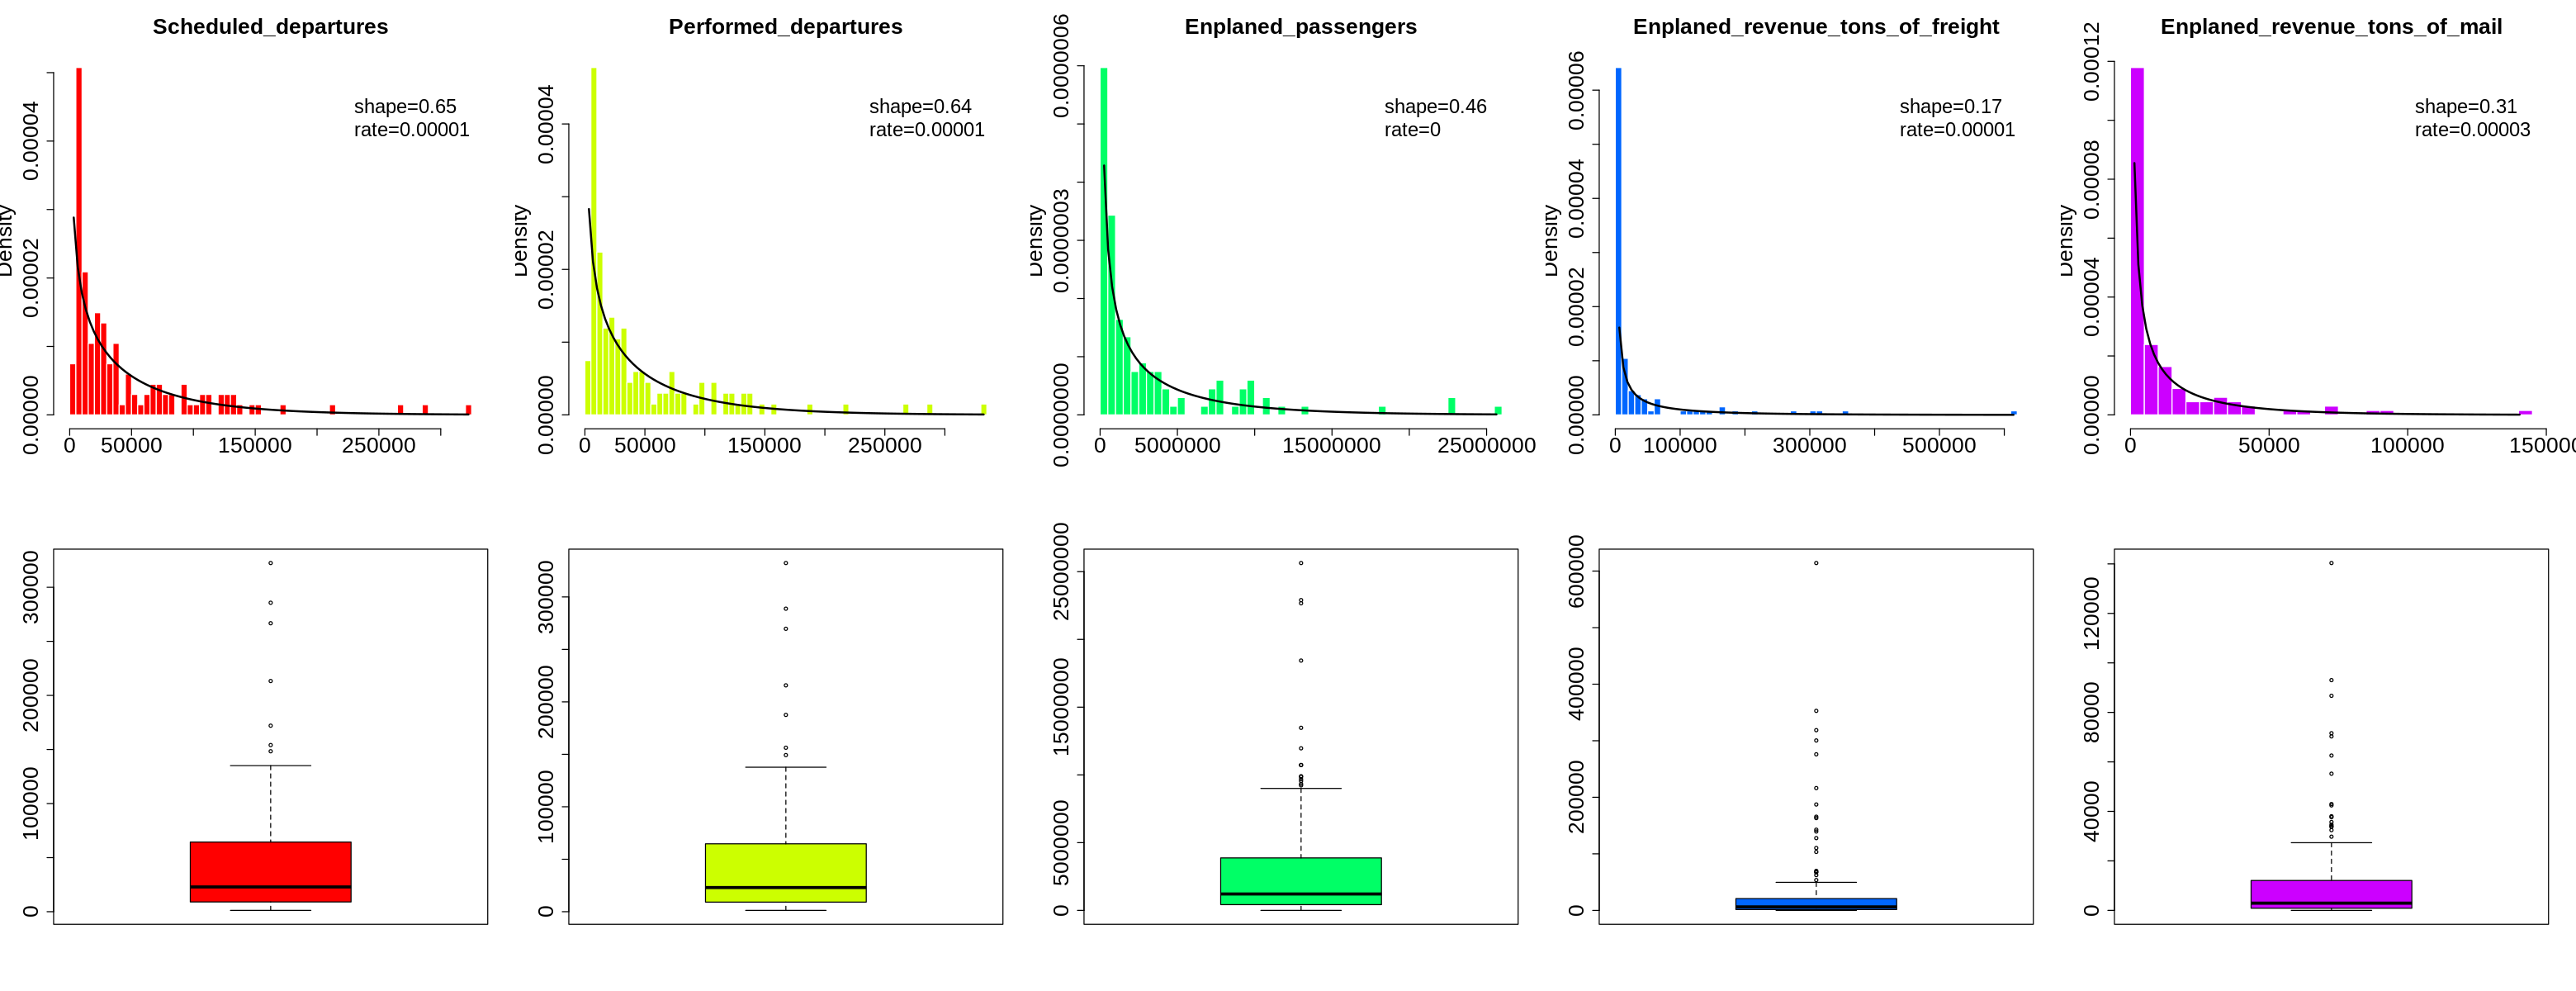

In [38]:
num_cols <- sapply(airport, is.numeric)

options(repr.plot.width = 26, repr.plot.height = 10)
par(mfrow = c(2, 5))

colormap <- rainbow(sum(num_cols))

for(i in 1:5)
{
  name = names(airport)[num_cols][i]
  h <- hist(
    airport[[name]],
    freq = FALSE,
    main = name,
    breaks = 50,
    xlab = "",
    col = colormap[i],
    border = "white",
    cex.main = 2,
    cex.lab = 2,
    cex.axis = 2
  )

  mean <- mean(airport[[name]])
  var <- var(airport[[name]])
  lambda <- mean/var
  p <- mean^2/var

  x_vals <- seq(0, max(airport[[name]]), length.out = 100)
  y_vals <- dgamma(x_vals, shape = p, rate = lambda)

  lines(x_vals, y_vals, col = "black", lwd = 2)
  legend("topleft",
         legend = paste0("shape=", round(p, 2), "\n", "rate=", round(lambda, 5)),
         bty = "n", cex = 1.8)
}

for(i in 1:5)
{
  name = names(airport)[num_cols][i]
  boxplot(
    airport[[name]],
    main = "",
    xlab = "",
    col = colormap[i],
    cex.lab = 2,
    cex.axis = 2
  )
}

Как видно из графиков, все величины хорошо приближаются гамма распределением с параметрами представленными в легендах. Можно также заметить, что у всех величин имеются выбросы, плотность запланированного количества грузоперевозок сильно сконцентрирована вблизи нуля, что соответствует малому параметру shape ~ 0.17. Оценки параметров гамма распределения произведены на основании известных мат. ожидания и дисперсии а также их выборочных эквивалентов при условии сходимости по распределению при росте числа выборки вторых к первым.

In [32]:
options(scipen = 999)
stats <- data.frame(
  min = sapply(airport[, num_cols], min),
  Q1 = sapply(airport[, num_cols], quantile, probs = 0.25),
  median = sapply(airport[, num_cols], median),
  Q3 = sapply(airport[, num_cols], quantile, probs = 0.75),
  max = sapply(airport[, num_cols], max),
  mean = sapply(airport[, num_cols], mean),
  var = sapply(airport[, num_cols], var),
  sd = sapply(airport[, num_cols], sd)
)

stats_t <- as.data.frame(t(stats))

stats_t

,Scheduled_departures,Performed_departures,Enplaned_passengers,Enplaned_revenue_tons_of_freight,Enplaned_revenue_tons_of_mail
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
min,1188.00,1253.00,0.0,7.950,0.0000
Q1,9049.00,9195.00,424246.8,1540.135,876.8825
median,22864.50,23027.50,1210722.0,6195.270,2919.5350
Q3,63643.75,64196.75,3865530.2,20558.923,11968.0175
max,322430.00,332338.00,25636383.0,614223.600,140359.3800
mean,45562.43,46304.96,3136191.9,33858.158,11461.8725
var,3202940994.01,3331108570.31,21202724262073.8,6575904728.800,423491499.2470
sd,56594.53,57715.76,4604641.6,81091.952,20578.9091


In [34]:
cor_matrix <- round(cor(airport[, num_cols]), 3)
cor_matrix

,Scheduled_departures,Performed_departures,Enplaned_passengers,Enplaned_revenue_tons_of_freight,Enplaned_revenue_tons_of_mail
Scheduled_departures,1.000,1.000,0.985,0.593,0.899
Performed_departures,1.000,1.000,0.985,0.593,0.899
Enplaned_passengers,0.985,0.985,1.000,0.582,0.913
Enplaned_revenue_tons_of_freight,0.593,0.593,0.582,1.000,0.667
Enplaned_revenue_tons_of_mail,0.899,0.899,0.913,0.667,1.000


Как видим, имеется сильная корреляция между: запланированными и совершенными перелетами, запланированными пассажирами и запланированными и совершенными перелетами, а также запланированной почтой и количеством перевозок и пассажиров

In [45]:
widths_vec <- c(8, 8, 8, 8)
babyboom <- read.fwf(
  file = "/content/R-statistics-spbu/lab1/datasets/babyboom.dat.txt",
  widths = widths_vec,
  col.names = c(
    "Time_of_birth",
    "Sex",
    "Birth_weight_in_grams",
    "Number_of_minutes_after_midnight_of_each_birth"
  ),
  strip.white = TRUE
)

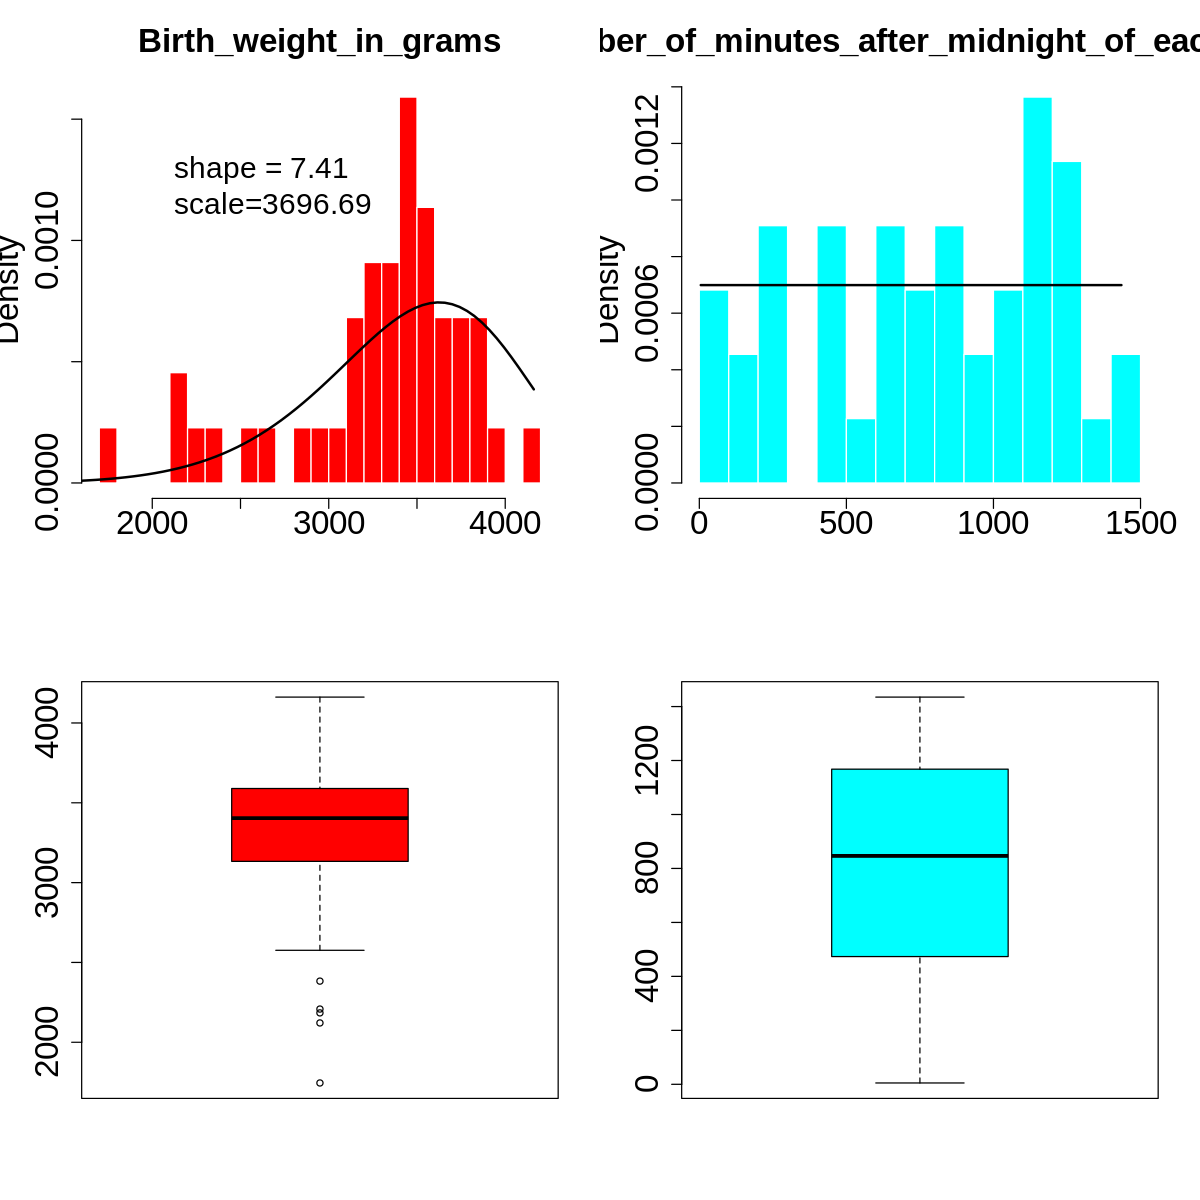

In [77]:
num_cols <- c(FALSE, FALSE, TRUE, TRUE)

options(repr.plot.width = 10, repr.plot.height = 10)
par(mfrow = c(2, 2))

colormap <- rainbow(sum(num_cols))

for(i in 1:2)
{
  name = names(babyboom)[num_cols][i]
  h <- hist(
    babyboom[[name]],
    freq = FALSE,
    main = name,
    breaks = 20,
    xlab = "",
    col = colormap[i],
    border = "white",
    cex.main = 2,
    cex.lab = 2,
    cex.axis = 2
  )
if(i == 1)
{
  x <- babyboom[[name]]
  m1 <- mean(x)
  m2 <- mean(x^2)

  weibull_equation <- function(k) {
    gamma1 <- gamma(1 + 1/k)
    gamma2 <- gamma(1 + 2/k)
    ratio <- m2 / (m1^2)
    return(ratio - gamma2 / (gamma1^2))
  }

  k <- uniroot(weibull_equation, c(0.1, 10))$root
  lambda <- m1 / gamma(1 + 1/k)

  x_vals <- seq(0, max(babyboom[[name]]), length.out = 100)
  y_vals <- dweibull(x_vals, shape = k, scale = lambda)

  lines(x_vals, y_vals, col = "black", lwd = 2)
  legend("topleft",
         legend = paste0("shape = ", round(k, 2), "\n", "scale=", round(lambda, 2)),
         bty = "n", cex = 1.8)
}
else
{
  min = min(babyboom[[name]])
  max = max(babyboom[[name]])

  x_vals <- seq(min, max, length.out = 2)
  y_vals <- dunif(x_vals, min = min, max = max)
  lines(x_vals, y_vals, col = "black", lwd = 2)
}
}

for(i in 1:2)
{
  name = names(babyboom)[num_cols][i]
  boxplot(
    babyboom[[name]],
    main = "",
    xlab = "",
    col = colormap[i],
    cex.lab = 2,
    cex.axis = 2
  )
}

первое распределение хорошо аппроксимируется распределением Вейбулла, о втором можно предположить что оно равномерное с учетом небольшого размера выборки, можно также заметить что оно не имеет выбросов. для распределения вейбулла мы подбирали параметры методом моментов
\begin{align*}
\text{Моменты Вейбулла:} & \\
E[X] &= \lambda \cdot \Gamma\left(1 + \frac{1}{k}\right) \\
E[X^2] &= \lambda^2 \cdot \Gamma\left(1 + \frac{2}{k}\right) \\
\\
\text{Метод моментов:} & \\
m_1 &= \lambda \cdot \Gamma\left(1 + \frac{1}{k}\right) \\
m_2 &= \lambda^2 \cdot \Gamma\left(1 + \frac{2}{k}\right) \\
\\
\text{Исключаем } \lambda: & \\
\lambda &= \frac{m_1}{\Gamma\left(1 + \frac{1}{k}\right)} \\
\frac{m_2}{m_1^2} &= \frac{\Gamma\left(1 + \frac{2}{k}\right)}{\left[\Gamma\left(1 + \frac{1}{k}\right)\right]^2}
\end{align*}

In [79]:
stats <- data.frame(
  min = sapply(babyboom[, num_cols], min),
  Q1 = sapply(babyboom[, num_cols], quantile, probs = 0.25),
  median = sapply(babyboom[, num_cols], median),
  Q3 = sapply(babyboom[, num_cols], quantile, probs = 0.75),
  max = sapply(babyboom[, num_cols], max),
  mean = sapply(babyboom[, num_cols], mean),
  var = sapply(babyboom[, num_cols], var),
  sd = sapply(babyboom[, num_cols], sd)
)

stats_t <- as.data.frame(t(stats))

stats_t

,Birth_weight_in_grams,Number_of_minutes_after_midnight_of_each_birth
,<dbl>,<dbl>
min,1745.0000,5.0000
Q1,3141.5000,482.7500
median,3404.0000,846.5000
Q3,3571.7500,1158.5000
max,4162.0000,1435.0000
mean,3275.9545,788.7273
var,278818.2770,173111.6913
sd,528.0325,416.0669


In [80]:
cor_matrix <- round(cor(babyboom[, num_cols]), 3)
cor_matrix

,Birth_weight_in_grams,Number_of_minutes_after_midnight_of_each_birth
Birth_weight_in_grams,1.00,0.08
Number_of_minutes_after_midnight_of_each_birth,0.08,1.00


наши величины очень слабо коррелируют, что в целом интуитивно